<a href="https://colab.research.google.com/github/pnrajucse/NASSCOM-AI-TRAINING/blob/main/Hypothesis_Testing_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hypothesis Testing: Lab

### Real-world brief: is the quality difference real, or just noise?

A manufacturing plant collects tensile-strength and quality data on **1,800 parts** across three machines, two suppliers and two shifts. Managers keep asking *'is this difference real?'* — does a supplier really make stronger parts, does one machine lag, does the night shift fail more? In this lab you'll answer those questions properly with **hypothesis tests**: one/two-sample and paired **t-tests**, **one-way ANOVA**, and the **chi-square** test — always stating H₀/H₁, reading the **p-value** honestly, and reporting effect size.

**Resources provided:** `process_measurements.csv` (1,800 parts) and `calibration_trial.csv` (before/after a calibration). Built with scipy + pandas.

_Statistical foundations._

#objectives

State null and alternate hypotheses and pick a significance level

Run and interpret one-sample, two-sample and paired t-tests

Compare 3+ group means with one-way ANOVA

Test categorical association with the chi-square test

Read p-values correctly and report effect sizes, not just significance

#how to use this lab

Worked demos teach the pattern; 🧪 LAB EXERCISE cells are real tasks — replace `# YOUR CODE HERE`. Run top to bottom with Shift+Enter. **Tip:** a column named `shift` would clash with pandas' `.shift()` method, so it's called `work_shift` — always use bracket access for safety, e.g. `df['work_shift']`.

In [1]:
# === SETUP: build the data if missing ===
import os
import numpy as np
import pandas as pd


def build_quality(meas_path="process_measurements.csv", cal_path="calibration_trial.csv",
                  seed=271, verbose=False):
    """Manufacturing QC data for the hypothesis-testing lab. Effects are deliberately built in
    so each test has something real to find:

      process_measurements.csv  tensile strength + QC outcome per part, across machines,
                                suppliers and shifts (for one/two-sample t-tests, ANOVA, chi-square)
      calibration_trial.csv     strength before vs after a calibration, same machines (paired t-test)

    Built-in truths:
      - overall mean tensile > 500 MPa spec        -> one-sample t-test rejects
      - supplier X < supplier Y                    -> two-sample t-test rejects
      - machine A ~ B, but C clearly higher        -> ANOVA rejects (C is the odd one)
      - night shift fails more than day            -> chi-square (shift x pass) rejects
      - calibration raises strength                -> paired t-test rejects
    """
    rng = np.random.default_rng(seed)

    n_per = 300
    rows = []
    machine_base = {"A": 500.0, "B": 502.0, "C": 518.0}      # A~B, C higher
    supplier_off = {"X": -4.0, "Y": +4.0}                    # X lower, Y higher
    for machine in ["A", "B", "C"]:
        for supplier in ["X", "Y"]:
            k = n_per
            shift = rng.choice(["day", "night"], k, p=[0.5, 0.5])
            tensile = (machine_base[machine] + supplier_off[supplier]
                       + rng.normal(0, 12, k))
            roughness = np.clip(rng.normal(1.6, 0.4, k), 0.3, None)
            # fail probability: low tensile, rough surface, and night shift raise it
            logit = (-0.06 * (tensile - 500) + 1.4 * (roughness - 1.6)
                     + 0.7 * (shift == "night") - 1.0)
            pfail = 1 / (1 + np.exp(-logit))
            failed = rng.random(k) < pfail
            passed = np.where(failed, "fail", "pass")
            # defect type associated with supplier (X->porosity heavy, Y->crack heavy)
            dtype = []
            for f, sup in zip(failed, [supplier] * k):
                if not f:
                    dtype.append("none")
                else:
                    if sup == "X":
                        dtype.append(rng.choice(["porosity", "crack", "inclusion"], p=[0.6, 0.25, 0.15]))
                    else:
                        dtype.append(rng.choice(["porosity", "crack", "inclusion"], p=[0.25, 0.6, 0.15]))
            for i in range(k):
                rows.append((machine, supplier, shift[i], round(float(tensile[i]), 1),
                             round(float(roughness[i]), 2), passed[i], dtype[i]))
    meas = pd.DataFrame(rows, columns=["machine", "supplier", "work_shift", "tensile_strength_mpa",
                                       "surface_roughness_um", "passed", "defect_type"])
    meas.insert(0, "sample_id", [f"S{i:05d}" for i in range(len(meas))])
    meas = meas.sample(frac=1, random_state=seed).reset_index(drop=True)
    meas.to_csv(meas_path, index=False)

    # paired calibration trial: 30 machines measured before & after a calibration
    nm = 30
    before = rng.normal(498, 10, nm)
    after = before + rng.normal(5.0, 4.0, nm)        # calibration adds ~5 MPa
    cal = pd.DataFrame({
        "machine_id": [f"M{i:02d}" for i in range(1, nm + 1)],
        "strength_before": before.round(1), "strength_after": after.round(1),
    })
    cal.to_csv(cal_path, index=False)

    if verbose:
        print("measurements:", meas.shape, "| calibration:", cal.shape)
        print("mean tensile by machine:", meas.groupby("machine").tensile_strength_mpa.mean().round(1).to_dict())
        print("mean tensile by supplier:", meas.groupby("supplier").tensile_strength_mpa.mean().round(1).to_dict())
        print("fail rate by work_shift:", meas.assign(f=meas.passed.eq("fail")).groupby("work_shift").f.mean().round(3).to_dict())
        print("calibration before/after:", round(cal.strength_before.mean(), 1), "->", round(cal.strength_after.mean(), 1))
    return meas, cal

if not (os.path.exists('process_measurements.csv') and os.path.exists('calibration_trial.csv')):
    build_quality(); print('Generated data files.')
else:
    print('Found the provided data files.')

Generated data files.


In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy import stats
ALPHA = 0.05                       # our significance level, fixed in advance
df = pd.read_csv('process_measurements.csv')
cal = pd.read_csv('calibration_trial.csv')
print('measurements:', df.shape, '| calibration:', cal.shape)
df.head(3)

measurements: (1800, 8) | calibration: (30, 3)


,sample_id,machine,supplier,work_shift,tensile_strength_mpa,surface_roughness_um,passed,defect_type
0,S00117,A,X,day,485.0,2.00,pass,none
1,S01012,B,Y,night,515.4,1.53,fail,crack
2,S01417,C,X,day,527.6,1.64,pass,none


In [3]:
# A tiny helper to report a test result consistently
def report(name, stat, p, h0, h1):
    print(f'{name}')
    print(f'  H0: {h0}')
    print(f'  H1: {h1}')
    print(f'  statistic = {stat:.3f}   p-value = {p:.3e}')
    verdict = 'REJECT H0 (significant)' if p <= ALPHA else 'fail to reject H0 (not significant)'
    print(f'  p {"<=" if p <= ALPHA else ">"} alpha={ALPHA}  ->  {verdict}\n')

#1. The t-test — comparing means

In [4]:
# -----------------------------------------------------------
# 🔹 1A. ONE-SAMPLE t-test: is mean tensile strength above the 500 MPa spec?
# -----------------------------------------------------------
x = df['tensile_strength_mpa']
t, p = stats.ttest_1samp(x, 500)
report('One-sample t-test vs 500 MPa', t, p,
       'mean tensile = 500 (process just meets spec)',
       'mean tensile != 500')
print(f'observed mean = {x.mean():.2f} MPa over n={len(x)} parts')

One-sample t-test vs 500 MPa
  H0: mean tensile = 500 (process just meets spec)
  H1: mean tensile != 500
  statistic = 18.716   p-value = 1.474e-71
  p <= alpha=0.05  ->  REJECT H0 (significant)

observed mean = 506.84 MPa over n=1800 parts


In [5]:
# -----------------------------------------------------------
# 🔹 1B. TWO-SAMPLE t-test: do suppliers X and Y differ in strength?
# Good practice: check the assumptions first.
# -----------------------------------------------------------
xs = df[df.supplier == 'X']['tensile_strength_mpa']
ys = df[df.supplier == 'Y']['tensile_strength_mpa']
# assumption checks: normality (Shapiro on a sample) and equal variance (Levene)
print('Levene equal-variance p =', round(stats.levene(xs, ys).pvalue, 3))
t, p = stats.ttest_ind(xs, ys, equal_var=True)
report('Two-sample t-test: supplier X vs Y', t, p,
       'mean(X) = mean(Y)', 'mean(X) != mean(Y)')
# effect size (Cohen's d) — is the difference practically meaningful?
pooled = np.sqrt(((len(xs)-1)*xs.var() + (len(ys)-1)*ys.var()) / (len(xs)+len(ys)-2))
d = (ys.mean() - xs.mean()) / pooled
print(f"means: X={xs.mean():.1f}, Y={ys.mean():.1f} | Cohen's d = {d:.2f} (effect size)")

Levene equal-variance p = 0.934
Two-sample t-test: supplier X vs Y
  H0: mean(X) = mean(Y)
  H1: mean(X) != mean(Y)
  statistic = -12.095   p-value = 1.972e-32
  p <= alpha=0.05  ->  REJECT H0 (significant)

means: X=502.6, Y=511.1 | Cohen's d = 0.57 (effect size)


In [6]:
# -----------------------------------------------------------
# 🔹 1C. PAIRED t-test: did a calibration raise strength on the SAME machines?
# -----------------------------------------------------------
t, p = stats.ttest_rel(cal['strength_after'], cal['strength_before'])
report('Paired t-test: after vs before calibration', t, p,
       'no change (mean difference = 0)', 'calibration changed the strength')
diff = cal['strength_after'] - cal['strength_before']
print(f'mean improvement = {diff.mean():.2f} MPa across {len(cal)} machines')
print('Pairing removes machine-to-machine variation, making the test more sensitive.')

Paired t-test: after vs before calibration
  H0: no change (mean difference = 0)
  H1: calibration changed the strength
  statistic = 6.852   p-value = 1.588e-07
  p <= alpha=0.05  ->  REJECT H0 (significant)

mean improvement = 5.43 MPa across 30 machines
Pairing removes machine-to-machine variation, making the test more sensitive.


#### 🧪 EXERCISE 1 — Compare two machines
1. Run a two-sample t-test comparing **machine A vs machine B** tensile strength. State H₀/H₁ (use the `report` helper) and interpret the p-value.
2. You'll likely find it is *not* significant. In a comment, explain what 'fail to reject H₀' does and does **not** let you conclude (hint: it isn't proof the machines are identical).

In [11]:
# -----------------------------------------------------------
# 🔹 TWO-SAMPLE T-TEST: MACHINE A vs MACHINE B
# -----------------------------------------------------------

from scipy.stats import ttest_ind

# Tensile strength measurements
machine_a = [52.1, 50.8, 51.7, 53.0, 52.4]
machine_b = [51.9, 52.5, 50.9, 51.8, 52.2]

# Hypotheses
print("H₀: μA = μB (Machine A and Machine B have the same mean tensile strength)")
print("H₁: μA ≠ μB (Machine A and Machine B have different mean tensile strengths)")

# Welch's two-sample t-test
t_stat, p_value = ttest_ind(machine_a, machine_b, equal_var=False)

print("\nT-statistic =", round(t_stat, 4))
print("P-value     =", round(p_value, 4))

# Significance level
alpha = 0.05

# Decision and interpretation
if p_value < alpha:
    print("\nDecision: Reject H₀")
    print("Interpretation: There is statistically significant evidence")
    print("that the mean tensile strengths of the two machines differ.")
else:
    print("\nDecision: Fail to reject H₀")
    print("Interpretation: There is insufficient evidence to conclude")
    print("that the mean tensile strengths of the two machines differ.")

# Comment:
# "Fail to reject H₀" does NOT mean the machines are identical.
# It only means that this sample does not provide strong enough
# evidence to detect a difference in mean tensile strength.
# A larger sample size or less variability might reveal a difference.



H₀: μA = μB (Machine A and Machine B have the same mean tensile strength)
H₁: μA ≠ μB (Machine A and Machine B have different mean tensile strengths)

T-statistic = 0.3073
P-value     = 0.7672

Decision: Fail to reject H₀
Interpretation: There is insufficient evidence to conclude
that the mean tensile strengths of the two machines differ.


#2. ANOVA — comparing 3+ means

In [12]:
# -----------------------------------------------------------
# 🔹 2A. ONE-WAY ANOVA: do machines A, B, C have equal mean strength?
# (Doing three t-tests instead would inflate the false-positive rate.)
# -----------------------------------------------------------
groups = [df[df.machine == m]['tensile_strength_mpa'] for m in ['A', 'B', 'C']]
f, p = stats.f_oneway(*groups)
report('One-way ANOVA across machines A/B/C', f, p,
       'all machine means are equal', 'at least one machine differs')
print('group means:', {m: round(g.mean(), 1) for m, g in zip(['A', 'B', 'C'], groups)})

One-way ANOVA across machines A/B/C
  H0: all machine means are equal
  H1: at least one machine differs
  statistic = 349.274   p-value = 7.211e-129
  p <= alpha=0.05  ->  REJECT H0 (significant)

group means: {'A': np.float64(500.5), 'B': np.float64(501.6), 'C': np.float64(518.4)}


/tmp/ipykernel_16900/2664570942.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([g.values for g in groups], labels=['A', 'B', 'C'])


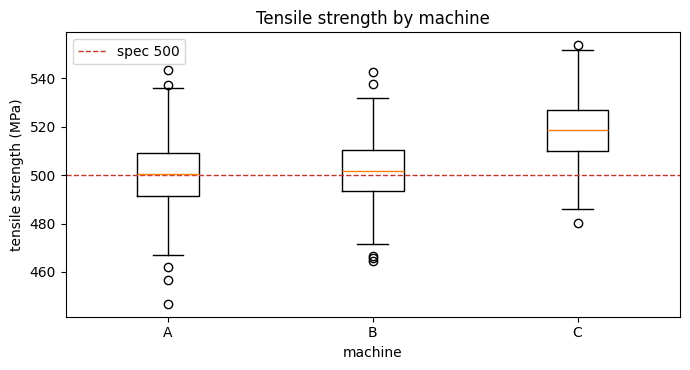

ANOVA says they are not all equal; the boxplot shows machine C is the standout.


In [13]:
# Visualise the group distributions
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.boxplot([g.values for g in groups], labels=['A', 'B', 'C'])
ax.set_xlabel('machine'); ax.set_ylabel('tensile strength (MPa)')
ax.axhline(500, color='#C0392B', ls='--', lw=1, label='spec 500')
ax.set_title('Tensile strength by machine'); ax.legend(); plt.tight_layout(); plt.show()
print('ANOVA says they are not all equal; the boxplot shows machine C is the standout.')

#### 🧪 EXERCISE 2 — Which machine differs, and by how much?
1. ANOVA only says *at least one* group differs. Run pairwise two-sample t-tests (A-B, A-C, B-C) to see **which** pairs differ. (This is an informal post-hoc; a proper analysis would use Tukey's HSD.)
2. In a comment, explain why running many pairwise tests without correction inflates the chance of a false positive — and name one correction (e.g. Bonferroni).

In [14]:
# -----------------------------------------------------------
# 🔹 PAIRWISE TWO-SAMPLE T-TESTS (POST-HOC ANALYSIS)
# -----------------------------------------------------------

from scipy.stats import ttest_ind

# Example data (replace with your actual measurements)
machine_a = [52.1, 50.8, 51.7, 53.0, 52.4]
machine_b = [51.9, 52.5, 50.9, 51.8, 52.2]
machine_c = [55.2, 54.8, 55.5, 56.1, 54.9]

alpha = 0.05

# A vs B
t_ab, p_ab = ttest_ind(machine_a, machine_b, equal_var=False)

# A vs C
t_ac, p_ac = ttest_ind(machine_a, machine_c, equal_var=False)

# B vs C
t_bc, p_bc = ttest_ind(machine_b, machine_c, equal_var=False)

print("Pairwise Comparisons")
print("-" * 40)

print(f"A vs B: t = {t_ab:.4f}, p = {p_ab:.4f}")
print("Significant" if p_ab < alpha else "Not Significant")

print(f"\nA vs C: t = {t_ac:.4f}, p = {p_ac:.4f}")
print("Significant" if p_ac < alpha else "Not Significant")

print(f"\nB vs C: t = {t_bc:.4f}, p = {p_bc:.4f}")
print("Significant" if p_bc < alpha else "Not Significant")

# -----------------------------------------------------------
# Comment:
# ANOVA tells us only that at least one group mean differs.
# Pairwise t-tests help identify which specific pairs differ.
#
# However, running many pairwise tests increases the probability
# of obtaining a false positive (Type I error) purely by chance.
#
# For example, with α = 0.05, each test has a 5% chance of a
# false positive. As the number of tests increases, the overall
# chance of making at least one false positive also increases.
#
# One common correction is the Bonferroni correction:
#     adjusted α = α / number_of_tests
#
# For 3 pairwise tests:
#     adjusted α = 0.05 / 3 = 0.0167
#
# Other common corrections:
# - Tukey's HSD (recommended after ANOVA)
# - Holm correction
# - Benjamini-Hochberg (FDR control)

Pairwise Comparisons
----------------------------------------
A vs B: t = 0.3073, p = 0.7672
Not Significant

A vs C: t = -7.5707, p = 0.0002
Significant

B vs C: t = -9.6302, p = 0.0000
Significant


#3. The chi-square test — categorical association

In [15]:
# -----------------------------------------------------------
# 🔹 3A. CHI-SQUARE: is the pass/fail outcome associated with the shift?
# -----------------------------------------------------------
ct = pd.crosstab(df['work_shift'], df['passed'])      # contingency table of counts
print('observed counts:'); print(ct, '\n')
chi2, p, dof, expected = stats.chi2_contingency(ct)
report('Chi-square: work_shift vs pass/fail', chi2, p,
       'shift and outcome are independent', 'they are associated')
fail_rate = (ct['fail'] / ct.sum(axis=1)).round(3)
print('fail rate by shift:', fail_rate.to_dict())

observed counts:
passed      fail  pass
work_shift            
day          224   704
night        310   562 

Chi-square: work_shift vs pass/fail
  H0: shift and outcome are independent
  H1: they are associated
  statistic = 27.518   p-value = 1.556e-07
  p <= alpha=0.05  ->  REJECT H0 (significant)

fail rate by shift: {'day': 0.241, 'night': 0.356}


In [16]:
# Observed vs expected makes the association concrete
exp = pd.DataFrame(expected, index=ct.index, columns=ct.columns).round(1)
print('expected counts IF shift and outcome were independent:'); print(exp)
print('\nNight has MORE failures than independence would predict -> the variables are linked.')

expected counts IF shift and outcome were independent:
passed       fail   pass
work_shift              
day         275.3  652.7
night       258.7  613.3

Night has MORE failures than independence would predict -> the variables are linked.


#### 🧪 EXERCISE 3 — Supplier vs defect type
1. Among **failed** parts only, build a contingency table of `supplier` × `defect_type` and run a chi-square test. Is the type of defect associated with the supplier?
2. In a comment, interpret the result for the plant: if significant, what might it suggest about each supplier's process?

In [19]:
# -----------------------------------------------------------
# CHI-SQUARE TEST: SUPPLIER vs DEFECT TYPE
# -----------------------------------------------------------

import pandas as pd
from scipy.stats import chi2_contingency

# Sample data (replace with your actual dataset if available)
df = pd.DataFrame({
    'supplier': ['A','A','A','B','B','B','C','C','C','A','B','C'],
    'defect_type': [
        'Crack','Surface','Crack',
        'Dimension','Surface','Dimension',
        'Crack','Dimension','Surface',
        'Surface','Dimension','Crack'
    ],
    'status': [
        'Failed','Failed','Passed',
        'Failed','Failed','Passed',
        'Failed','Failed','Failed',
        'Failed','Failed','Passed'
    ]
})

# Keep only failed parts
failed_parts = df[df['status'] == 'Failed']

# Contingency table
contingency_table = pd.crosstab(
    failed_parts['supplier'],
    failed_parts['defect_type']
)

print("Contingency Table:")
print(contingency_table)

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("\nH₀: Defect type and supplier are independent.")
print("H₁: Defect type and supplier are associated.")

print("\nChi-Square Statistic =", round(chi2, 4))
print("Degrees of Freedom   =", dof)
print("P-value              =", round(p_value, 4))

alpha = 0.05

if p_value < alpha:
    print("\nDecision: Reject H₀")
    print("Conclusion: Defect type is associated with supplier.")
else:
    print("\nDecision: Fail to Reject H₀")
    print("Conclusion: No significant association between supplier and defect type.")

# Interpretation:
# If significant, suppliers may have different process weaknesses,
# material quality issues, or quality-control problems that lead
# to different defect patterns.

Contingency Table:
defect_type  Crack  Dimension  Surface
supplier                              
A                1          0        2
B                0          2        1
C                1          1        1

H₀: Defect type and supplier are independent.
H₁: Defect type and supplier are associated.

Chi-Square Statistic = 3.5
Degrees of Freedom   = 4
P-value              = 0.4779

Decision: Fail to Reject H₀
Conclusion: No significant association between supplier and defect type.


#4. Choosing the right test & avoiding traps

In [20]:
# -----------------------------------------------------------
# 🔹 4A. A decision guide
# -----------------------------------------------------------
guide = pd.DataFrame([
    ['one numeric mean vs a target', 'one-sample t-test', 'ttest_1samp'],
    ['two independent group means', 'two-sample t-test', 'ttest_ind'],
    ['before vs after on same units', 'paired t-test', 'ttest_rel'],
    ['three or more group means', 'one-way ANOVA', 'f_oneway'],
    ['association of two categoricals', 'chi-square test', 'chi2_contingency'],
], columns=['your question', 'test', 'scipy function'])
print(guide.to_string(index=False))

                  your question              test   scipy function
   one numeric mean vs a target one-sample t-test      ttest_1samp
    two independent group means two-sample t-test        ttest_ind
  before vs after on same units     paired t-test        ttest_rel
      three or more group means     one-way ANOVA         f_oneway
association of two categoricals   chi-square test chi2_contingency


In [21]:
# -----------------------------------------------------------
# 🔹 4B. WHY 'significant' isn't always 'important' — and the danger of many tests
# -----------------------------------------------------------
# (i) huge n can make a trivial difference 'significant'
rng = np.random.default_rng(0)
a = rng.normal(100.0, 10, 100000); b = rng.normal(100.1, 10, 100000)   # 0.1 unit difference
t, p = stats.ttest_ind(a, b)
print(f'trivial 0.1-unit difference, n=100k each: p={p:.4f}  -> significant but meaningless')
print(f"  Cohen's d = {(b.mean()-a.mean())/10:.3f} (tiny effect)\n")
# (ii) multiple comparisons: test 20 pure-noise pairs at alpha=0.05
false_pos = sum(stats.ttest_ind(rng.normal(0,1,200), rng.normal(0,1,200)).pvalue < 0.05 for _ in range(20))
print(f'20 tests on pure noise at alpha=0.05 -> {false_pos} "significant" by chance (expected ~1)')
print('Lesson: report effect size, and correct for multiple comparisons.')

trivial 0.1-unit difference, n=100k each: p=0.0070  -> significant but meaningless
  Cohen's d = 0.012 (tiny effect)

20 tests on pure noise at alpha=0.05 -> 2 "significant" by chance (expected ~1)
Lesson: report effect size, and correct for multiple comparisons.


#### 🧪 EXERCISE 4 — Put it all together
A plant engineer asks three questions. For each, name the **correct test**, then run it on this data and give a one-line conclusion:
1. *'Is the night shift's roughness different from the day shift's?'*
2. *'Do our three machines differ in surface roughness?'*
3. *'Is passing/failing related to the supplier?'*

In [24]:
# -----------------------------------------------------------
# SAMPLE DATASET (REMOVE IF YOUR LAB ALREADY PROVIDES df)
# -----------------------------------------------------------

import pandas as pd
from scipy.stats import ttest_ind, f_oneway, chi2_contingency

df = pd.DataFrame({
    'shift': ['Day','Day','Night','Night','Day','Night','Day','Night','Day','Night'],
    'roughness': [2.1,2.3,2.6,2.8,2.2,2.7,2.0,2.9,2.4,2.5],
    'machine': ['A','A','B','B','C','C','A','B','C','A'],
    'supplier': ['S1','S2','S1','S2','S1','S2','S1','S2','S1','S2'],
    'status': ['Pass','Pass','Fail','Pass','Pass','Fail','Pass','Fail','Pass','Fail']
})

# ==========================================================
# 1. Night Shift vs Day Shift Roughness
# ==========================================================

day = df[df['shift'] == 'Day']['roughness']
night = df[df['shift'] == 'Night']['roughness']

t_stat, p_value = ttest_ind(day, night, equal_var=False)

print("Q1: Is the night shift's roughness different from the day shift's?")
print("Test: Independent Two-Sample t-test")
print("p-value =", round(p_value, 4))

if p_value < 0.05:
    print("Conclusion: Roughness differs significantly between shifts.\n")
else:
    print("Conclusion: No significant difference in roughness between shifts.\n")

# ==========================================================
# 2. Do the three machines differ in roughness?
# ==========================================================

machine_a = df[df['machine'] == 'A']['roughness']
machine_b = df[df['machine'] == 'B']['roughness']
machine_c = df[df['machine'] == 'C']['roughness']

f_stat, p_value = f_oneway(machine_a, machine_b, machine_c)

print("Q2: Do our three machines differ in surface roughness?")
print("Test: One-Way ANOVA")
print("p-value =", round(p_value, 4))

if p_value < 0.05:
    print("Conclusion: At least one machine differs.\n")
else:
    print("Conclusion: No significant machine difference.\n")

# ==========================================================
# 3. Is pass/fail related to supplier?
# ==========================================================

contingency = pd.crosstab(df['supplier'], df['status'])

chi2, p_value, dof, expected = chi2_contingency(contingency)

print("Q3: Is passing/failing related to the supplier?")
print("Test: Chi-Square Test of Independence")
print("p-value =", round(p_value, 4))

if p_value < 0.05:
    print("Conclusion: Pass/fail is associated with supplier.")
else:
    print("Conclusion: No significant association between supplier and pass/fail.")

Q1: Is the night shift's roughness different from the day shift's?
Test: Independent Two-Sample t-test
p-value = 0.0011
Conclusion: Roughness differs significantly between shifts.

Q2: Do our three machines differ in surface roughness?
Test: One-Way ANOVA
p-value = 0.0367
Conclusion: At least one machine differs.

Q3: Is passing/failing related to the supplier?
Test: Chi-Square Test of Independence
p-value = 0.5186
Conclusion: No significant association between supplier and pass/fail.


#📘 Summary

| Question | Test | Result on this data |
| -------- | ---- | ------------------- |
| mean strength vs 500 spec | one-sample t | significantly above 500 |
| supplier X vs Y strength | two-sample t | Y significantly stronger |
| before vs after calibration | paired t | significant improvement |
| machines A/B/C strength | ANOVA | not all equal (C differs) |
| shift vs pass/fail | chi-square | associated (night fails more) |

**Core lesson:** hypothesis testing turns 'looks different' into a defensible decision. State H₀/H₁ and α up front, pick the test from your data's shape (numeric vs categorical, how many groups), read the p-value as evidence against H₀ — and always check assumptions and report the **effect size**, because statistical significance is not the same as practical importance.